# Deep Learning Project — WikiArt Image Classification

In [1]:
import zipfile
import os
import shutil
import random
import matplotlib.pyplot as plt
import numpy as np

dataset_path = "data/raw/wikiart"

if not os.path.exists(dataset_path):
    os.makedirs("data/raw", exist_ok=True)
    with zipfile.ZipFile("wikiart.zip", "r") as z:
        z.extractall("data/raw")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


## Data Split

Split the raw dataset into **train / validation / test** folders (70 / 15 / 15) with stratified sampling per artist.  
The split only runs if the target directories do not already exist.

In [2]:
train_dir = "data/train"
val_dir   = "data/val"
test_dir  = "data/test"

SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO = 0.15  (remainder)

if not all(os.path.exists(d) for d in [train_dir, val_dir, test_dir]):
    random.seed(SEED)

    classes = sorted(os.listdir(dataset_path))
    for cls in classes:
        src = os.path.join(dataset_path, cls)
        images = sorted(os.listdir(src))
        random.shuffle(images)

        n = len(images)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)

        splits = {
            train_dir: images[:n_train],
            val_dir:   images[n_train:n_train + n_val],
            test_dir:  images[n_train + n_val:],
        }

        for split_dir, file_list in splits.items():
            dst = os.path.join(split_dir, cls)
            os.makedirs(dst, exist_ok=True)
            for fname in file_list:
                shutil.copy2(os.path.join(src, fname), os.path.join(dst, fname))

    print("Data split complete.")
    for name, d in [("Train", train_dir), ("Val", val_dir), ("Test", test_dir)]:
        total = sum(len(os.listdir(os.path.join(d, c))) for c in os.listdir(d))
        print(f"  {name}: {total} images")
else:
    print("Split directories already exist — skipping.")
    for name, d in [("Train", train_dir), ("Val", val_dir), ("Test", test_dir)]:
        total = sum(len(os.listdir(os.path.join(d, c))) for c in os.listdir(d))
        print(f"  {name}: {total} images")

Data split complete.
  Train: 9326 images
  Val: 1992 images
  Test: 2022 images


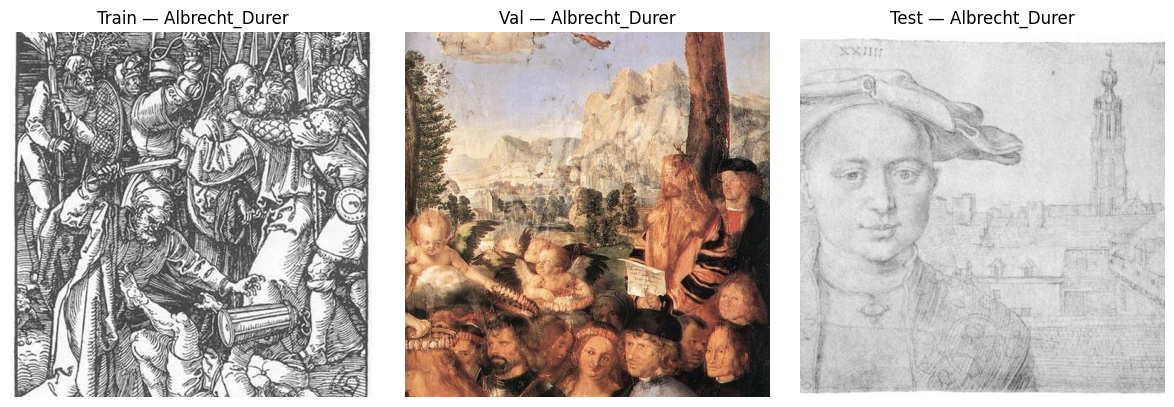

In [3]:
# Quick sanity check: show one sample per split
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, d) in zip(axes, [("Train", train_dir), ("Val", val_dir), ("Test", test_dir)]):
    cls = sorted(os.listdir(d))[0]
    img_path = os.path.join(d, cls, os.listdir(os.path.join(d, cls))[0])
    ax.imshow(plt.imread(img_path))
    ax.set_title(f"{name} — {cls}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Baseline CNN Model

A minimal Convolutional Neural Network to establish a baseline:
- 3 Conv2D + MaxPooling blocks
- Global Average Pooling → Dense → Softmax (23 classes)
- Images resized to **128 × 128** for fast iteration

In [4]:
import keras
from keras import layers

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 23

# --- Data generators with basic rescaling ---
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    seed=SEED,
)

val_ds = keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    seed=SEED,
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    seed=SEED,
)

class_names = train_ds.class_names
print(f"Classes ({len(class_names)}): {class_names}")

I0000 00:00:1774177314.791413    5304 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 9326 files belonging to 23 classes.


W0000 00:00:1774177317.198187    5304 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1774177317.209310    5304 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1774177317.314019    5304 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5252 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:2b:00.0, compute capability: 12.0a


Found 1992 files belonging to 23 classes.
Found 2022 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [5]:
# Prefetch for performance
AUTOTUNE = keras.backend.backend()  # just need tf.data.AUTOTUNE
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# --- Build the model ---
model = keras.Sequential([
    # Rescale pixel values to [0, 1]
    layers.Rescaling(1.0 / 255, input_shape=(*IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

/home/lucas/Desktop/Deep-learning-project/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,727 (440.34 KB)

 Trainable params: 112,727 (440.34 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [6]:
EPOCHS = 20

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
)

Epoch 1/20


I0000 00:00:1774177320.583570    7931 service.cc:153] XLA service 0x7ee770004600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774177320.583593    7931 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774177320.642986    7931 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774177320.789485    7931 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774177320.819733    7931 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2224__.45


 16/292 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0872 - loss: 3.1162

I0000 00:00:1774177324.864169    7931 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


286/292 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1173 - loss: 3.0062

I0000 00:00:1774177328.256389    7930 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2224__.45


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1179 - loss: 3.0043

I0000 00:00:1774177333.595923    8607 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 4 bytes spill stores, 4 bytes spill loads



292/292 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.1494 - loss: 2.9119 - val_accuracy: 0.2209 - val_loss: 2.6864
Epoch 2/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2190 - loss: 2.6737 - val_accuracy: 0.2646 - val_loss: 2.5286
Epoch 3/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2467 - loss: 2.5856 - val_accuracy: 0.2731 - val_loss: 2.4472
Epoch 4/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2657 - loss: 2.4826 - val_accuracy: 0.2771 - val_loss: 2.4126
Epoch 5/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2822 - loss: 2.4098 - val_accuracy: 0.3283 - val_loss: 2.2871
Epoch 6/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3078 - loss: 2.3072 - val_accuracy: 0.3394 - val_loss: 2.2001
Epoch 7/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3384 - loss: 2.2302 - val_accuracy: 0.3529 - val_loss: 2.1312
Epoch 8/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3492 - loss: 2.1630 - val_accuracy: 0.35

### Learning Curves

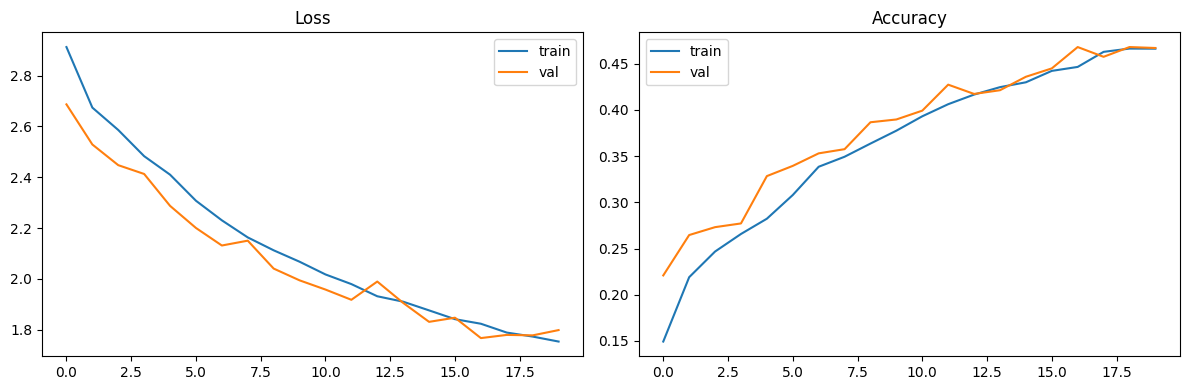

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="val")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(history.history["accuracy"], label="train")
ax2.plot(history.history["val_accuracy"], label="val")
ax2.set_title("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

### Test Evaluation

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Collect predictions
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4708 - loss: 1.7670

Test Loss: 1.7670
Test Accuracy: 0.4708

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.59      0.63      0.61        87
      Boris_Kustodiev       0.62      0.15      0.24        68
     Camille_Pissarro       0.43      0.37      0.40        94
        Childe_Hassam       0.50      0.19      0.27        59
         Claude_Monet       0.46      0.52      0.49       141
          Edgar_Degas       0.33      0.05      0.08        65
        Eugene_Boudin       0.65      0.56      0.60        59
         Gustave_Dore       0.60      0.89      0.71        80
           Ilya_Repin       0.49      0.29      0.37        58
      Ivan_Aivazovsky       0.68      0.74      0.71        62
        Ivan_Shishkin       0.52      0.30      0.38        56
  John_Singer_Sargent       0.42      0.57      0.48        83
         Marc_Chagall       0.32      0.2

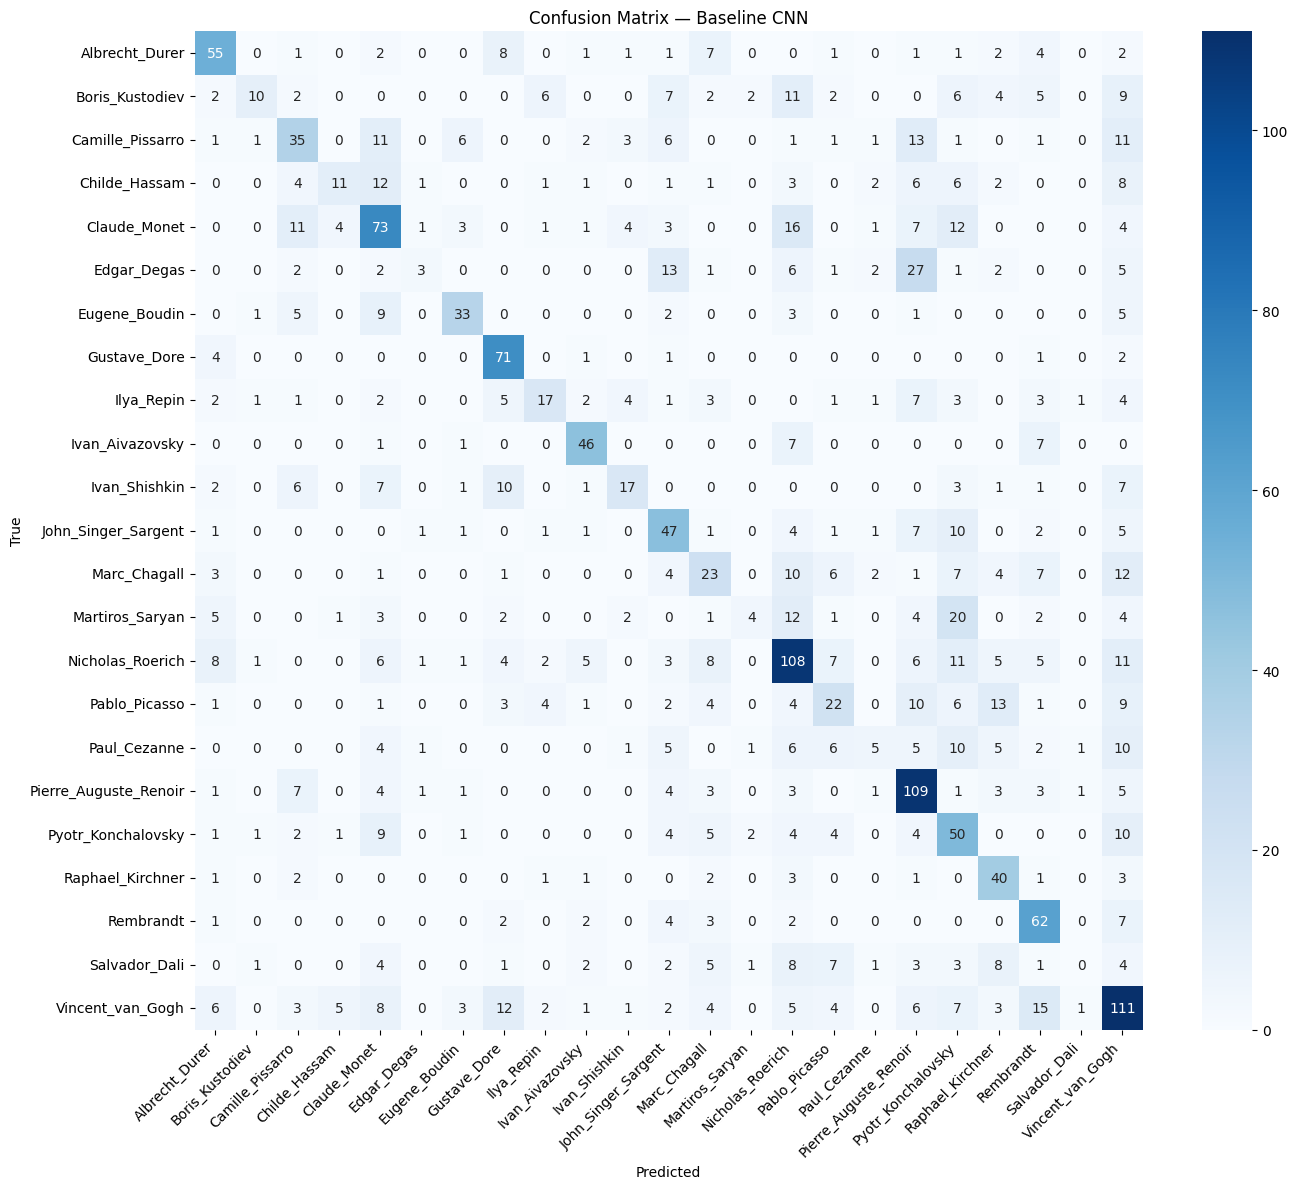

In [9]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Baseline CNN")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()